# Bandit benchmark notebook

Этот ноутбук запускает benchmark-пайплайн (аналогично `src/run_benchmark.py`) на вашем датасете.

## 1) Настройки

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    CatBoostPolicy,
    LogisticTSLibPolicy,
    PartitionedTSLibPolicy,
    RandomPolicy,
    EpsilonGreedyPolicy,
    UCBPolicy,
    ThompsonSamplingPolicy,
    build_expected_reward_estimator,
    core_scenarios,
    default_five_scenarios,
    make_simulated_environment,
    preprocess_bandit_dataframe,
    run_scenarios,
    split_train_test_by_date,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


In [2]:
# Укажите путь к данным (.tsv или .parquet)
DATA_PATH = ROOT / 'data' / 'events.tsv'
PREPARED_TRAIN_PATH = ROOT / 'artifacts' / 'datasets' / 'train_prepared.parquet'
PREPARED_TEST_PATH = ROOT / 'artifacts' / 'datasets' / 'test_prepared.parquet'
USE_PREPARED_SPLITS = True
TEST_RATIO = 0.5
EPSILON = 0.1
SEED = 42
SIMULATE = False
STOCHASTIC_SIM = True
FULL_SCENARIOS = False


## 2) Загрузка и препроцессинг

In [3]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    # Stage 1: load -> split -> filter -> save
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(ROOT / 'artifacts' / 'datasets'), TEST_RATIO, SEED)
    # Stage 2: scale features and save prepared datasets
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(ROOT / 'artifacts' / 'datasets'))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 12701839 test(random only): 3925311


## 3) Конфиг политик и сценариев

In [4]:
policy_factories = {
    'random': lambda: RandomPolicy(seed=SEED),
    'epsilon_greedy': lambda: EpsilonGreedyPolicy(epsilon=EPSILON, seed=SEED),
    'ucb': lambda: UCBPolicy(),
    'thompson_sampling': lambda: ThompsonSamplingPolicy(seed=SEED),
}

try:
    import catboost  # noqa: F401
    policy_factories['catboost No update'] = lambda: CatBoostPolicy(random_seed=SEED,can_update_online=False)
except Exception:
    print('catboost is unavailable: skipping CatBoostPolicy')

try:
    import contextualbandits  # noqa: F401
    policy_factories['logistic_ts No update'] = lambda: LogisticTSLibPolicy(random_seed=SEED, can_update_online=False)
    policy_factories['logistic_ts Refit History'] = lambda: LogisticTSLibPolicy(random_seed=SEED, can_update_online=True)
    policy_factories['partitioned_ts No update'] = lambda: PartitionedTSLibPolicy(random_seed=SEED, can_update_online=False)
    policy_factories['partitioned_ts Refit History'] = lambda: PartitionedTSLibPolicy(random_seed=SEED, can_update_online=True)
except Exception:
    print('contextualbandits is unavailable: skipping LogisticTS/PartitionedTS')

scenarios = default_five_scenarios() if FULL_SCENARIOS else core_scenarios()

## 4) Запуск benchmark

In [10]:
train_df2 = train_df.sample(fraction=0.5, shuffle=True).sort("date")
test_df2 = test_df.sample(fraction=0.2, shuffle=True).sort("date")

In [11]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_df2,
    test_df=test_df2,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']

display(metrics_df)
print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)


case_2_random_pretrain_online_update/

case_2_random_pretrain_online_update/random: train_unique_actions=50
case_2_random_pretrain_online_update/random: step=32467, date=2026-02-02 00:00:00, unique_actions_total=50, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/random: step=90611, date=2026-02-03 00:00:00, unique_actions_total=51, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/random: step=133178, date=2026-02-04 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/random: step=174798, date=2026-02-05 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/random: step=206822, date=2026-02-06 00:00:00, unique_actions_total=52, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/random: step=236702, date=2026-02-07 00:00:00, unique_actions_total=52, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/random: step=258030, date=2026-02-08 00:00:00, unique_actions_total=52, un

case_2_random_pretrain_online_update/

case_2_random_pretrain_online_update/epsilon_greedy: train_unique_actions=50
case_2_random_pretrain_online_update/epsilon_greedy: step=32467, date=2026-02-02 00:00:00, unique_actions_total=50, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/epsilon_greedy: step=90611, date=2026-02-03 00:00:00, unique_actions_total=51, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/epsilon_greedy: step=133178, date=2026-02-04 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/epsilon_greedy: step=174798, date=2026-02-05 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/epsilon_greedy: step=206822, date=2026-02-06 00:00:00, unique_actions_total=52, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/epsilon_greedy: step=236702, date=2026-02-07 00:00:00, unique_actions_total=52, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/epsilon_greedy: st

case_2_random_pretrain_online_update/

...

case_2_random_pretrain_online_update/partitioned_ts No update: train_unique_actions=50
case_2_random_pretrain_online_update/partitioned_ts No update: step=32467, date=2026-02-02 00:00:00, unique_actions_total=50, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/partitioned_ts No update: step=90611, date=2026-02-03 00:00:00, unique_actions_total=51, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/partitioned_ts No update: step=133178, date=2026-02-04 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/partitioned_ts No update: step=174798, date=2026-02-05 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/partitioned_ts No update: step=206822, date=2026-02-06 00:00:00, unique_actions_total=52, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/partitioned_ts No update: step=236702, date=2026-02-07 00:00:00, unique_actions_total=52, unique_action

case_2_random_pretrain_online_update/

case_2_random_pretrain_online_update/partitioned_ts Refit History: train_unique_actions=50
case_2_random_pretrain_online_update/partitioned_ts Refit History: step=32467, date=2026-02-02 00:00:00, unique_actions_total=50, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/partitioned_ts Refit History: step=90611, date=2026-02-03 00:00:00, unique_actions_total=51, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/partitioned_ts Refit History: step=133178, date=2026-02-04 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/partitioned_ts Refit History: step=174798, date=2026-02-05 00:00:00, unique_actions_total=51, unique_actions_new_in_day=0
case_2_random_pretrain_online_update/partitioned_ts Refit History: step=206822, date=2026-02-06 00:00:00, unique_actions_total=52, unique_actions_new_in_day=1
case_2_random_pretrain_online_update/partitioned_ts Refit History: step=236702, date=2026-02-07 00:00:00, unique_act

,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,train_unique_actions,scenario,algo
0,785062,552535,9204.0,0.016658,13368.0,0.017028,0.703811,2025.479239,0.003666,9877.519441,0.012582,50,case_2_random_pretrain_online_update,random
1,785062,552074,10995.0,0.019916,18262.0,0.023262,0.703223,349.416824,0.000633,8086.519441,0.010300,50,case_2_random_pretrain_online_update,epsilon_greedy
2,785062,554876,11051.0,0.019916,18257.0,0.023255,0.706793,324.011387,0.000584,8030.519441,0.010229,50,case_2_random_pretrain_online_update,ucb
3,785062,552927,11295.0,0.020428,19060.0,0.024278,0.704310,65.955264,0.000119,7786.519441,0.009918,50,case_2_random_pretrain_online_update,thompson_sampling
4,785062,552035,10800.0,0.019564,17564.0,0.022373,0.703174,524.937172,0.000951,8281.519441,0.010549,50,case_2_random_pretrain_online_update,catboost No update
5,785062,554539,9641.0,0.017386,14678.0,0.018697,0.706363,1709.253792,0.003082,9440.519441,0.012025,50,case_2_random_pretrain_online_update,logistic_ts No update
6,785062,552509,11149.0,0.020179,18716.0,0.023840,0.703778,208.910596,0.000378,7932.519441,0.010104,50,case_2_random_pretrain_online_update,logistic_ts Refit History
7,785062,554164,9585.0,0.017296,14476.0,0.018439,0.705886,1718.220332,0.003101,9496.519441,0.012097,50,case_2_random_pretrain_online_update,partitioned_ts No update
8,785062,551921,10561.0,0.019135,16930.0,0.021565,0.703029,734.351089,0.001331,8520.519441,0.010853,50,case_2_random_pretrain_online_update,partitioned_ts Refit History


history rows: 4977580


## 5) Графики по сценариям

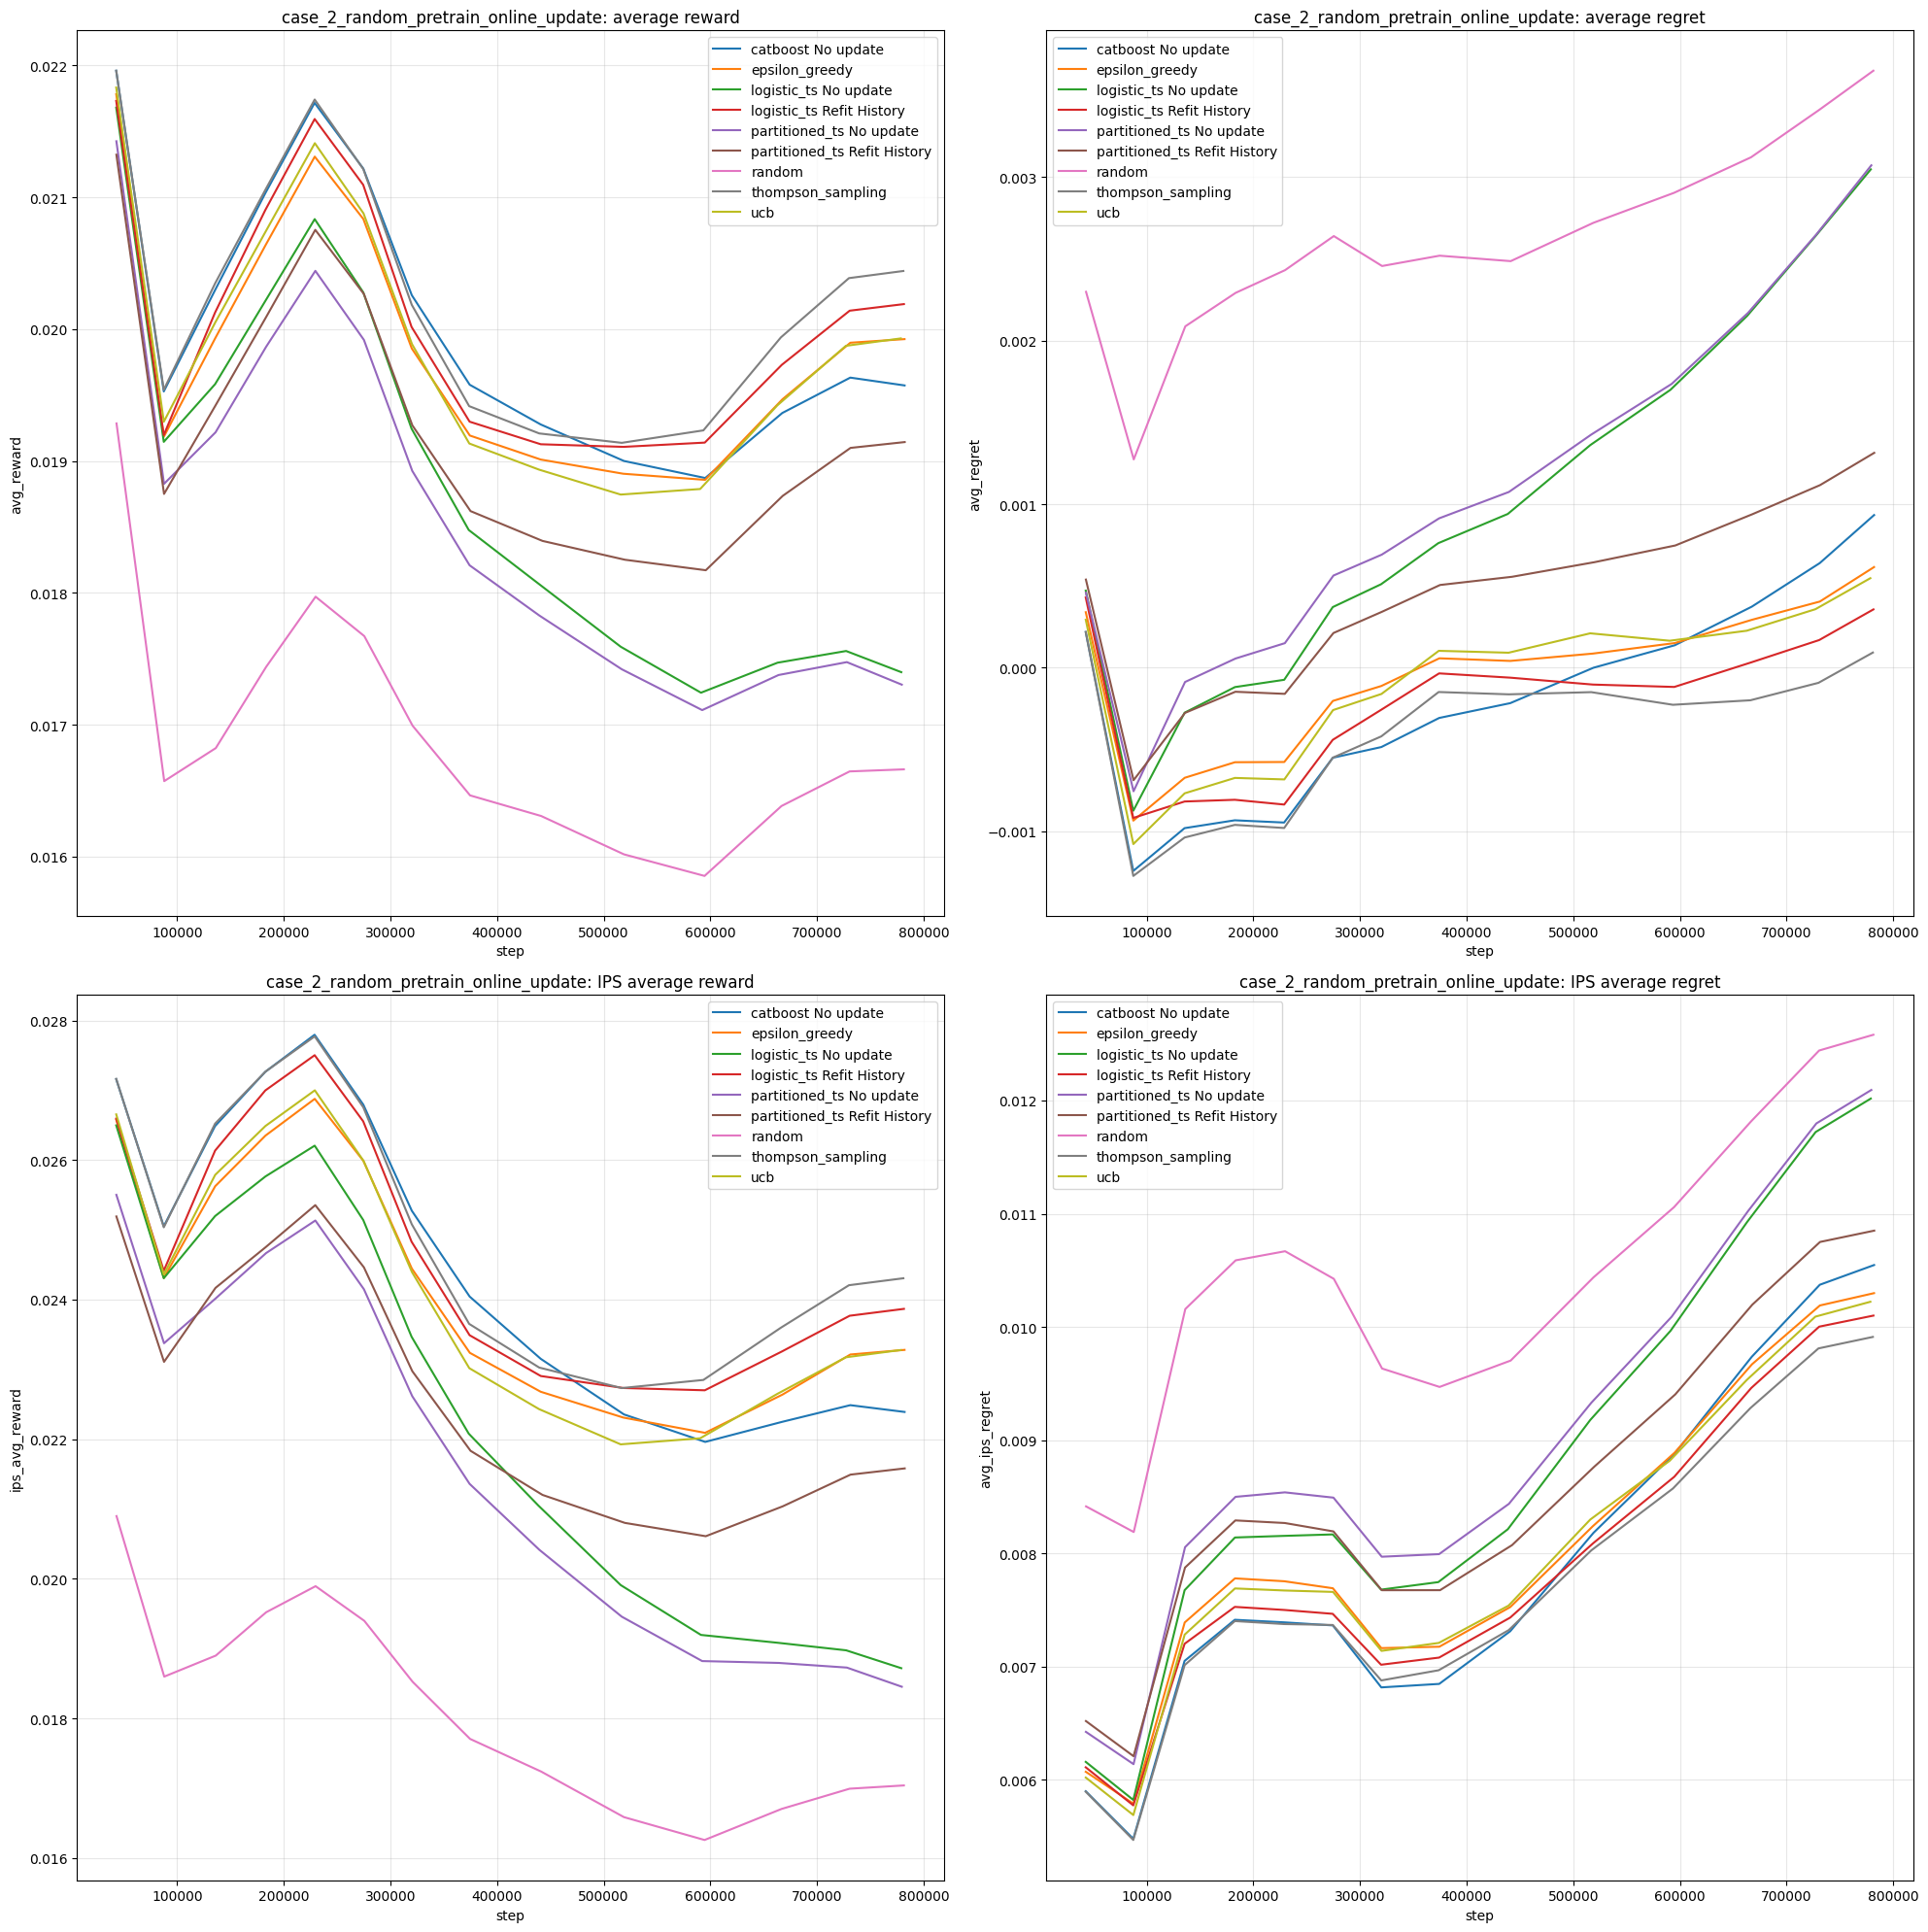

In [14]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')
        # axes[0, 1].set_yscale('log')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')
        # axes[1, 1].set_yscale('log')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')

## 6) Графики по статистикам action'ов
Показывает динамику общего числа уникальных action'ов и количества новых action'ов по дням/checkpoint'ам.

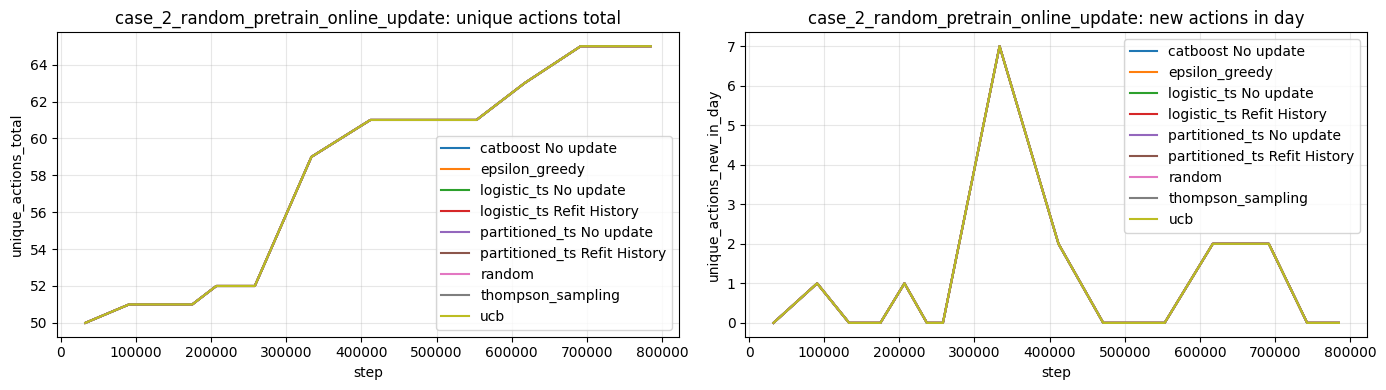

In [13]:
if not action_stats_df.empty:
    for scenario_name, part in action_stats_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            algo_df = algo_df.sort_values('step')
            axes[0].plot(algo_df['step'], algo_df['unique_actions_total'], label=algo)
            axes[1].plot(algo_df['step'], algo_df['unique_actions_new_in_day'], label=algo)

        axes[0].set_title(f"{scenario_name}: unique actions total")
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('unique_actions_total')

        axes[1].set_title(f"{scenario_name}: new actions in day")
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('unique_actions_new_in_day')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('action_stats_df is empty.')


## 7) Сохранение артефактов

In [9]:
OUT_DIR = ROOT / 'artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics.csv'
history_path = OUT_DIR / 'history.csv'
action_stats_path = OUT_DIR / 'action_stats.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
action_stats_df.to_csv(action_stats_path, index=False)

print('saved metrics:', metrics_path)
print('saved history:', history_path)
print('saved action stats:', action_stats_path)


saved metrics: /Users/ogrobertino/BanditsResearch/artifacts/metrics.csv
saved history: /Users/ogrobertino/BanditsResearch/artifacts/history.csv
saved action stats: /Users/ogrobertino/BanditsResearch/artifacts/action_stats.csv
